In [2]:
# import packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Load the Dataset
PROJECT_DIR = Path.cwd().resolve().parent
DATA_PATH = PROJECT_DIR / "data" / "processed" / "matchupDiff.csv"

assert DATA_PATH.exists(), f"Missing file: {DATA_PATH}"

matchupDiff =  pd.read_csv(DATA_PATH)
matchupDiff.head()

,Unnamed: 0,Season,DayNum,WTeamID,LTeamID,WScore,LScore,team1Id,team2Id,y,...,Raw Defensive Efficiency Rank_diff,Raw Offensive Efficiency_diff,Raw Offensive Efficiency Rank_diff,Raw Tempo_diff,Raw Tempo Rank_diff,Seed_diff,StlRate_diff,TOPct_diff,Tempo_diff,eFGPct_diff
0,0,2003,134,1421,1411,92,84,1411,1421,0,...,-165,1.6,-43,1.1,-36,0,-0.0095,-1.0055,1.1023,1.6965
1,1,2003,136,1112,1436,80,51,1112,1436,1,...,-34,9.0,-133,10.0,-263,-15,0.0061,-2.4229,9.9893,2.7429
2,2,2003,136,1113,1272,84,71,1113,1272,0,...,123,3.2,-42,-0.7,25,3,-0.0261,0.1265,-0.6498,1.9572
3,3,2003,136,1141,1166,79,73,1141,1166,0,...,159,-5.4,34,3.3,-100,5,-0.0200,5.7503,3.3585,-0.0999
4,4,2003,136,1143,1301,76,74,1143,1301,1,...,-39,-1.7,19,2.2,-96,-1,-0.0206,-1.3144,2.1439,-1.0445


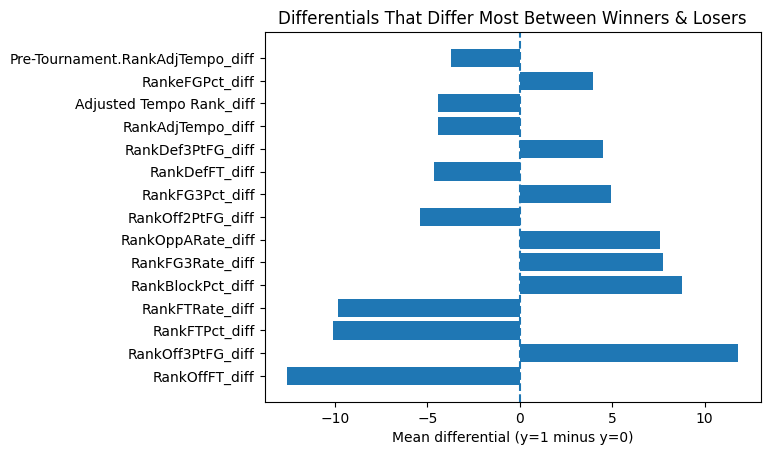

In [4]:
#1. Highest Differentials Between Winners and Losers
diff_cols = [c for c in matchupDiff.columns if c.endswith("_diff")]
means = matchupDiff.groupby("y")[diff_cols].mean()
mean_diff = (means.loc[1] - means.loc[0]).sort_values()
top = mean_diff.abs().sort_values(ascending=False).head(15).index
plt.barh(top, mean_diff[top])
plt.axvline(0, linestyle="--")
plt.title("Differentials That Differ Most Between Winners & Losers")
plt.xlabel("Mean differential (y=1 minus y=0)")
plt.show()

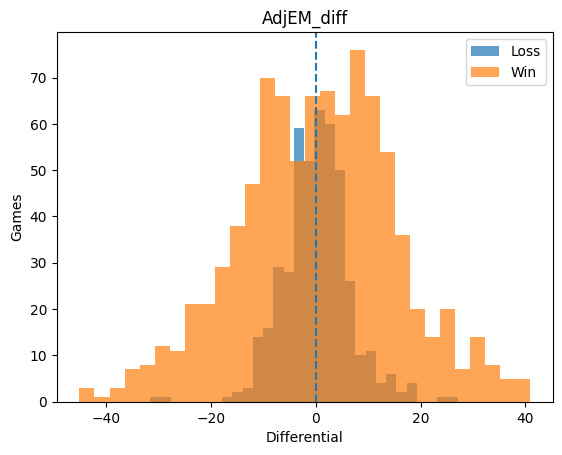

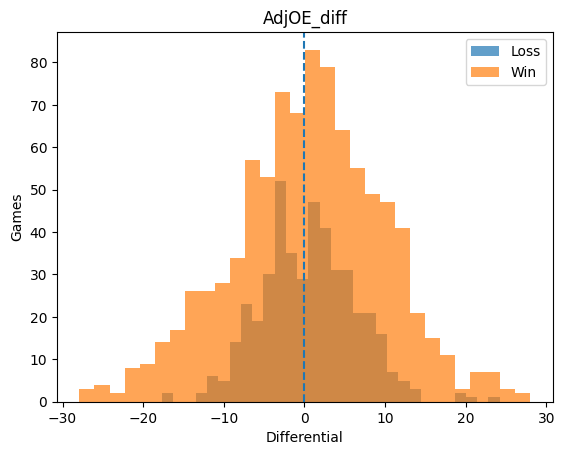

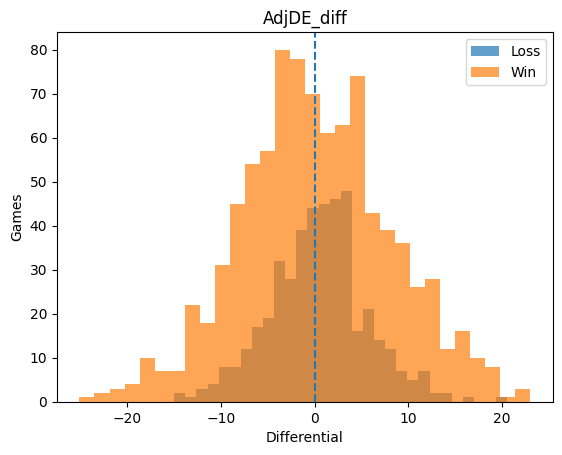

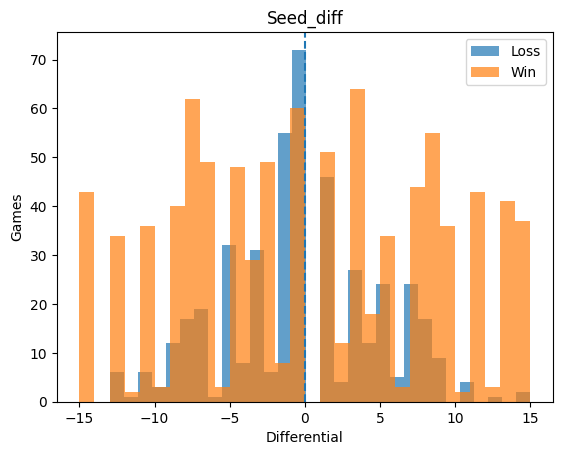

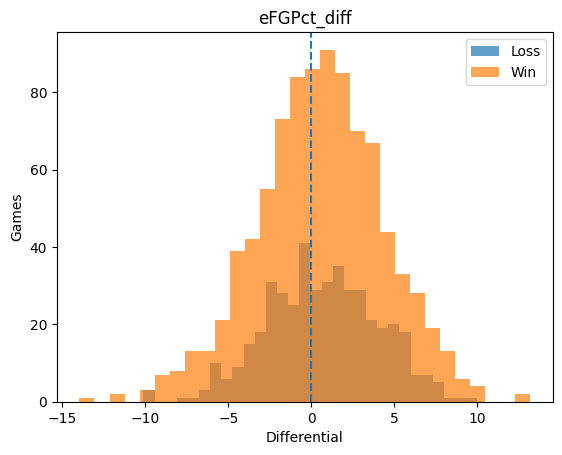

In [6]:
#2. Distributions of Winners and Losers for Key Statistics
features = [
    "AdjEM_diff",
    "AdjOE_diff",
    "AdjDE_diff",
    "Seed_diff",
    "eFGPct_diff"
]
for col in features:
    plt.figure()
    plt.hist(matchupDiff[matchupDiff["y"]==0][col], bins=30, alpha=0.7, label="Loss")
    plt.hist(matchupDiff[matchupDiff["y"]==1][col], bins=30, alpha=0.7, label="Win")
    plt.axvline(0, linestyle="--")
    plt.title(col)
    plt.xlabel("Differential")
    plt.ylabel("Games")
    plt.legend()
    plt.show()

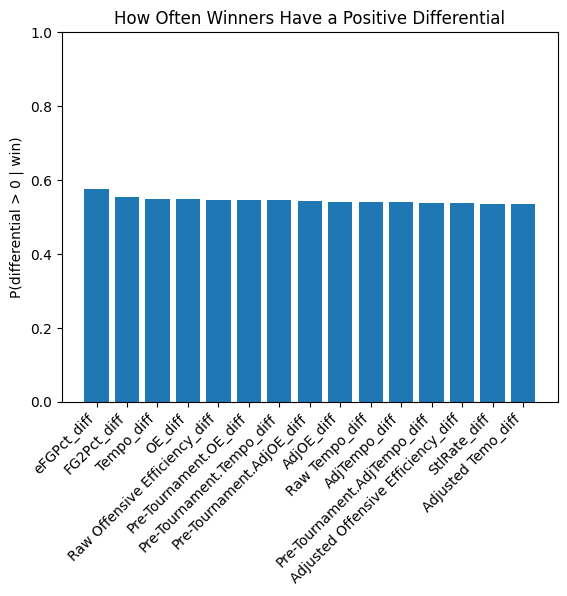

In [8]:
#3. Percentage that Winners Have a Positive Differential
pos_rate = {
    col: (matchupDiff[matchupDiff["y"] == 1][col] > 0).mean()
    for col in diff_cols
}
pos_rate = pd.Series(pos_rate).sort_values(ascending=False).head(15)
plt.bar(pos_rate.index,pos_rate.values)
plt.xticks(rotation=45, ha="right")
plt.ylim(0,1)
plt.ylabel("P(differential > 0 | win)")
plt.title("How Often Winners Have a Positive Differential")
plt.show()

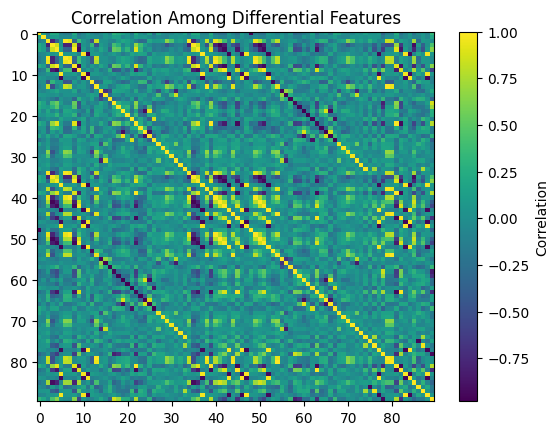

In [10]:
#4. Correlation Heatmap for Differential Features
corr = matchupDiff[diff_cols].corr()
plt.imshow(corr, aspect="auto")
plt.colorbar(label="Correlation")
plt.title("Correlation Among Differential Features")
plt.show()

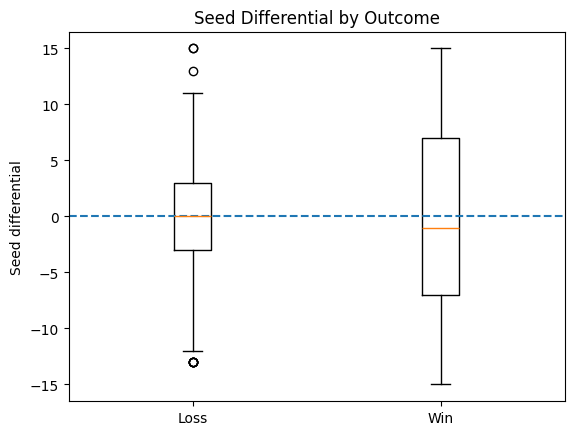

In [12]:
#5. Distribution of Seed Differentials for Wins and Losses
plt.figure()
plt.boxplot(
    [matchupDiff[matchupDiff["y"] == 0]["Seed_diff"].dropna(),
     matchupDiff[matchupDiff["y"] == 1]["Seed_diff"].dropna()],
    tick_labels=["Loss", "Win"]
)
plt.axhline(0, linestyle="--")
plt.ylabel("Seed differential")
plt.title("Seed Differential by Outcome")
plt.show()

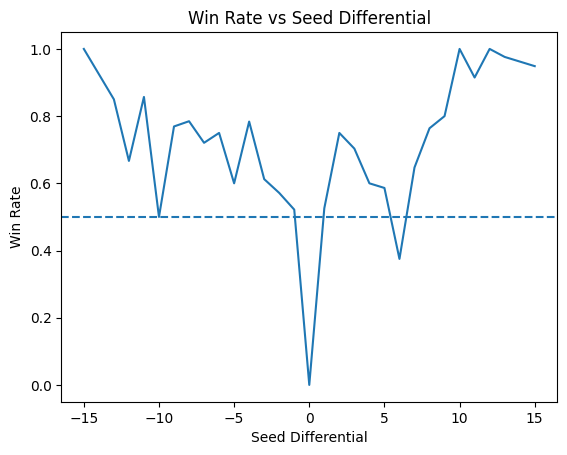

In [20]:
#6. Win rate for each seed difference
win_rate_seed = matchupDiff.groupby("Seed_diff")["y"].mean()

plt.figure()
plt.plot(win_rate_seed.index, win_rate_seed.values)
plt.axhline(0.5, linestyle="--")
plt.title("Win Rate vs Seed Differential")
plt.xlabel("Seed Differential")
plt.ylabel("Win Rate")
plt.show()


In [28]:
matchupDiff[matchupDiff["Seed_diff"] == 0]["y"].value_counts()

y
0    72
Name: count, dtype: int64